In [100]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import logomaker

seam_subset = pd.read_csv("/grid/koo/home/pmantill/projects/SEAM_validate/single_seq/seq_subsets/seam_seeds.csv")
seam_subset

,seq_idx,seq_id,pred,true,seq
0,3609,peak27535_Reversed:,1.765135,1.9285,AGGACCGGATCAACTCATAAACTGTTTTTTTGATCTGATAACCAAC...
1,3320,peak26256,1.732207,1.7780,AGGACCGGATCAACTTTGAACACGTAGGCACTGCCTGAGACAAAGA...
2,15776,peak84030,1.794500,1.7465,AGGACCGGATCAACTCTTGGAGACCCTGCCCAGGCAGGAGGCAAAT...
3,8467,peak49966_Reversed:,1.582142,1.7130,AGGACCGGATCAACTAAGTTAGCAAGTTTTGTGGATGCTGGCAGAA...
4,6001,peak38192_Reversed:,1.401627,1.5755,AGGACCGGATCAACTGGCTGTTCCCAGAGCACACGTCCTCCCCTCC...
5,18024,ENSG00000143384,1.414394,1.5225,AGGACCGGATCAACTCCCCGGCCCCGGCCCCGGCCCCGCCCCGGCC...
6,2074,peak20130,1.358207,1.5095,AGGACCGGATCAACTGACACTCTCCCTCTGAAGTAATTAGGGCAAA...
7,53,peak10288_Reversed:,1.640127,1.5065,AGGACCGGATCAACTTTCCCTTCTTGACTTTCTTGTGAACATCCCC...


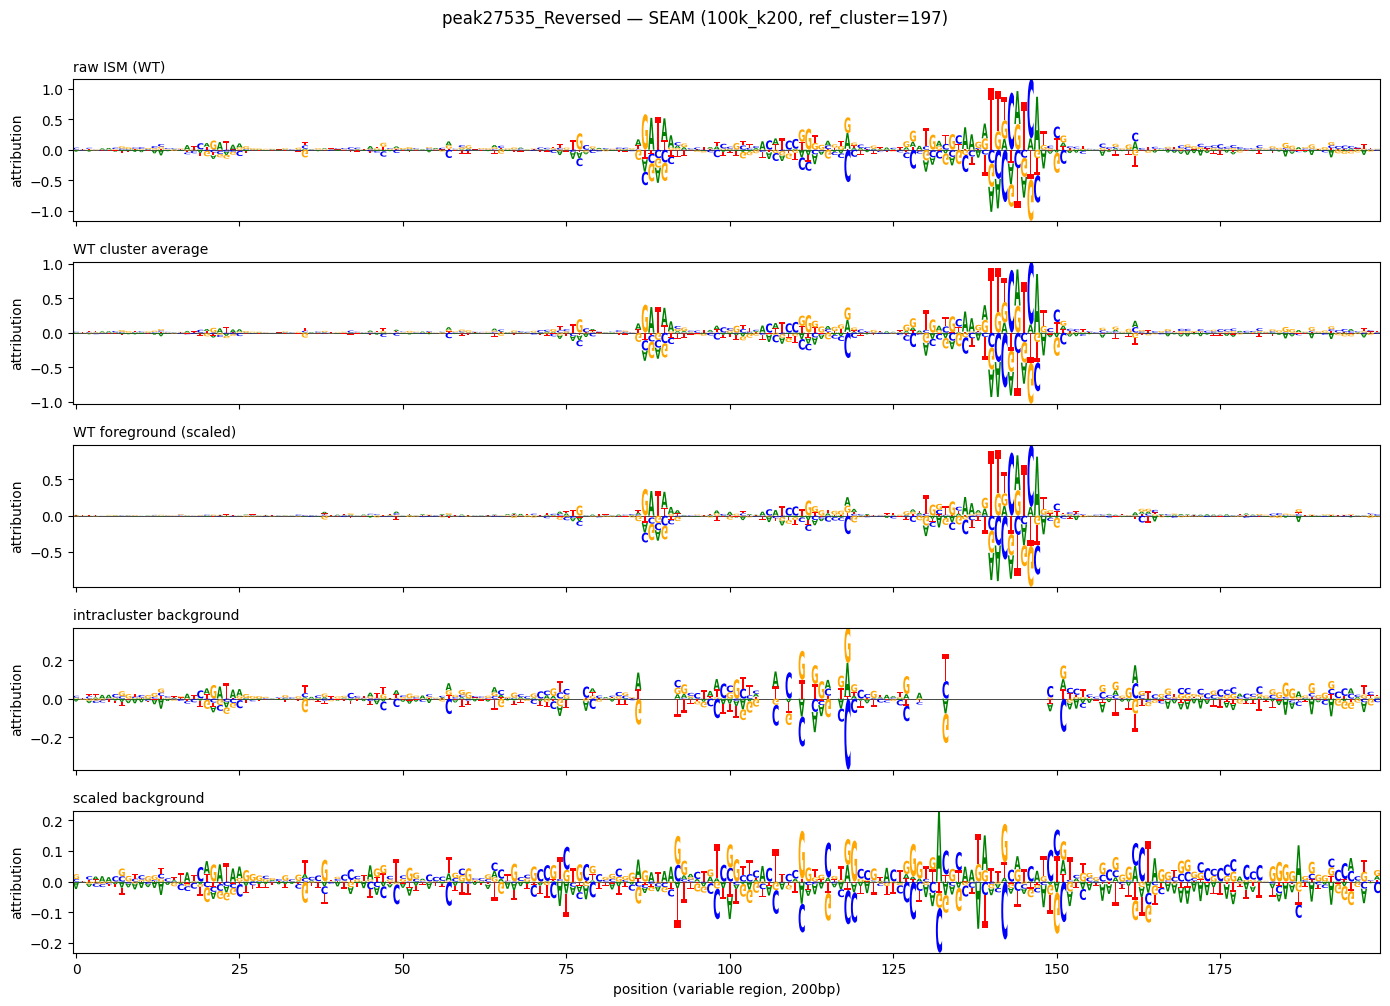

In [101]:
SEQ_ID = "peak27535_Reversed"        # single source of truth for the whole notebook

# CONFIG toggles the clustering run + matching library in one string:
#   "100k_k50"  -> foregrounds           + 100k libs (mutagenesis_lib / ism)
#   "100k_k100" -> foregrounds_kmeans100  + 100k libs
#   "100k_k200" -> foregrounds_kmeans200  + 100k libs
#   "200k_k100" -> foregrounds_200k       + 200k libs (mutagenesis_lib_200k / ism_200k)
CONFIG = "100k_k200"
FG_NAME, LIB_SUFFIX = {
    "100k_k50":  ("foregrounds", ""),
    "100k_k100": ("foregrounds_kmeans100", ""),
    "100k_k200": ("foregrounds_kmeans200", ""),
    "200k_k100": ("foregrounds_200k", "_200k"),
}[CONFIG]

fg_dir = Path(f"/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/{FG_NAME}/{SEQ_ID}")
ref_cluster_idx = int(np.load(fg_dir / "ref_cluster_idx.npy"))

logos = {
    "raw ISM (WT)":            np.load(fg_dir / "wt_attribution.npy"),
    "WT cluster average":      np.load(fg_dir / "ref_cluster_avg.npy"),
    "WT foreground (scaled)":  np.load(fg_dir / "foreground_scaled.npy"),
    "intracluster background": np.load(fg_dir / "cluster_backgrounds.npy")[ref_cluster_idx],
    "scaled background":       np.load(fg_dir / "average_background_scaled.npy"),
}

fig, axes = plt.subplots(len(logos), 1, figsize=(14, 2 * len(logos)), sharex=True)
for ax, (title, arr) in zip(axes, logos.items()):
    logomaker.Logo(pd.DataFrame(arr, columns=list("ACGT")), ax=ax)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("attribution")
axes[-1].set_xlabel("position (variable region, 200bp)")
fig.suptitle(f"{SEQ_ID} — SEAM ({CONFIG}, ref_cluster={ref_cluster_idx})", y=1.002)
plt.tight_layout()

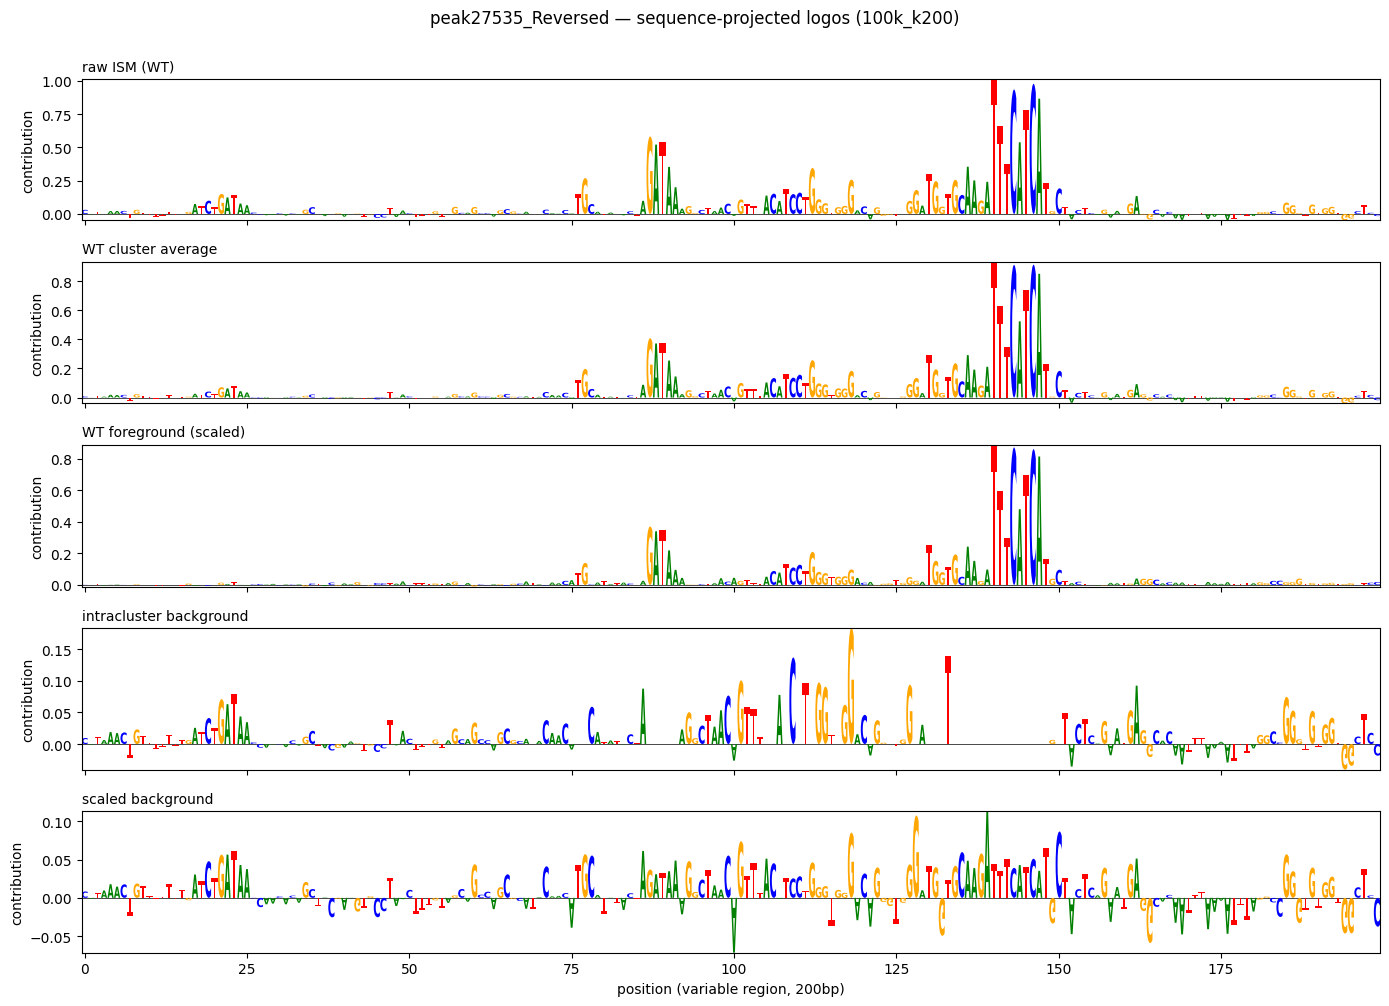

In [102]:
# same logos as above, projected to the WT sequence: (attribution * WT one-hot).sum over channels
import h5py
with h5py.File(f"/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib{LIB_SUFFIX}/{SEQ_ID}.h5") as f:
    wt_ohe = f["wt_sequence"][15:215, :]               # (200, 4) WT one-hot, variable region

fig, axes = plt.subplots(len(logos), 1, figsize=(14, 2 * len(logos)), sharex=True)
for ax, (title, arr) in zip(axes, logos.items()):
    proj = (arr * wt_ohe).sum(-1)                      # per-position contribution at the WT base
    logomaker.Logo(pd.DataFrame(wt_ohe * proj[:, None], columns=list("ACGT")), ax=ax)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("contribution")
axes[-1].set_xlabel("position (variable region, 200bp)")
fig.suptitle(f"{SEQ_ID} — sequence-projected logos ({CONFIG})", y=1.002)
plt.tight_layout()

In [103]:
# rebuild SEAM MetaExplainer from saved artifacts (no re-clustering, no model calls) to use its MSM
import h5py
from seam import Clusterer, MetaExplainer

R = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")

with h5py.File(R / f"mutagenesis_lib{LIB_SUFFIX}/{SEQ_ID}.h5") as f:
    var_seqs = f["sequences"][:, 15:215, :]        # (N, 200, 4) variable region
with h5py.File(R / f"ism{LIB_SUFFIX}/{SEQ_ID}.h5") as f:
    predictions = f["predictions"][:]              # (N,)
    attributions = f["ism_centered"][:]            # (N, 200, 4)
cluster_labels = np.load(fg_dir / "cluster_labels.npy")

seqs = ["".join(s) for s in np.array(list("ACGT"))[var_seqs.argmax(-1)]]
mave = pd.DataFrame({"Sequence": seqs, "DNN": predictions})   # row 0 = WT reference

clusterer = Clusterer(attributions, gpu=False)
clusterer.cluster_labels = cluster_labels
meta = MetaExplainer(clusterer, mave, attributions, ref_idx=0, sort_method="median", mut_rate=0.10)
meta.generate_msm(gpu=False)

Processing clusters: 100%|██████████| 200/200 [00:00<00:00, 2179.15it/s]


,Cluster,Position,Reference,Consensus,Entropy
0,0,0,100.000000,100.000000,-1.442695e-10
1,0,1,0.000000,100.000000,-1.442695e-10
2,0,2,0.000000,100.000000,-1.442695e-10
3,0,3,0.000000,100.000000,-1.442695e-10
4,0,4,0.000000,100.000000,-1.442695e-10
...,...,...,...,...,...
39995,199,195,8.979592,91.020408,5.700259e-01
39996,199,196,13.061224,86.938776,7.630369e-01
39997,199,197,10.612245,89.387755,6.500759e-01
39998,199,198,11.020408,88.979592,6.526233e-01


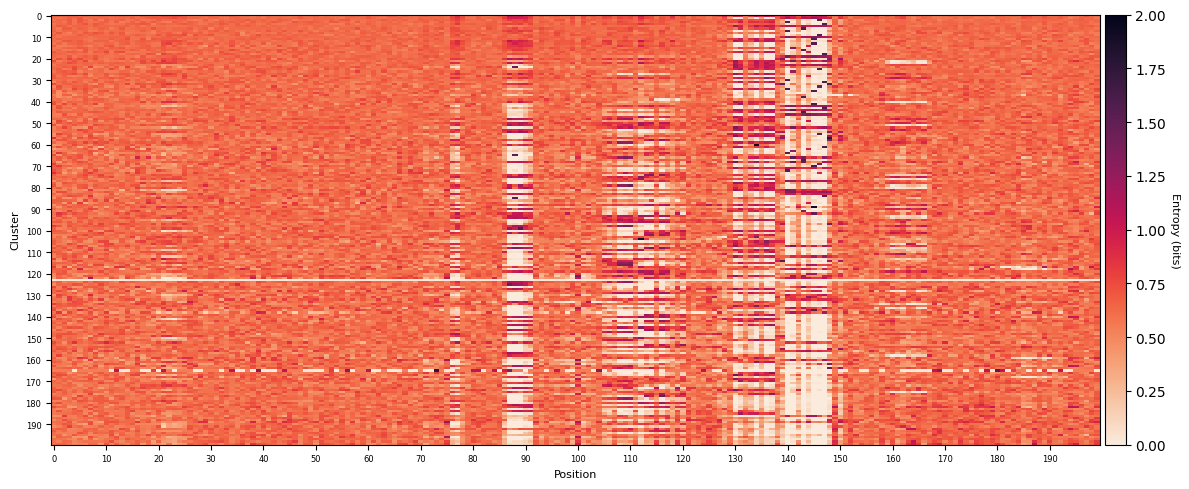

(<Figure size 1200x500 with 2 Axes>,
 <Axes: xlabel='Position', ylabel='Cluster'>)

In [104]:
# cluster summary matrix - entropy
meta.plot_msm(column="Entropy", figsize=(12, 5))

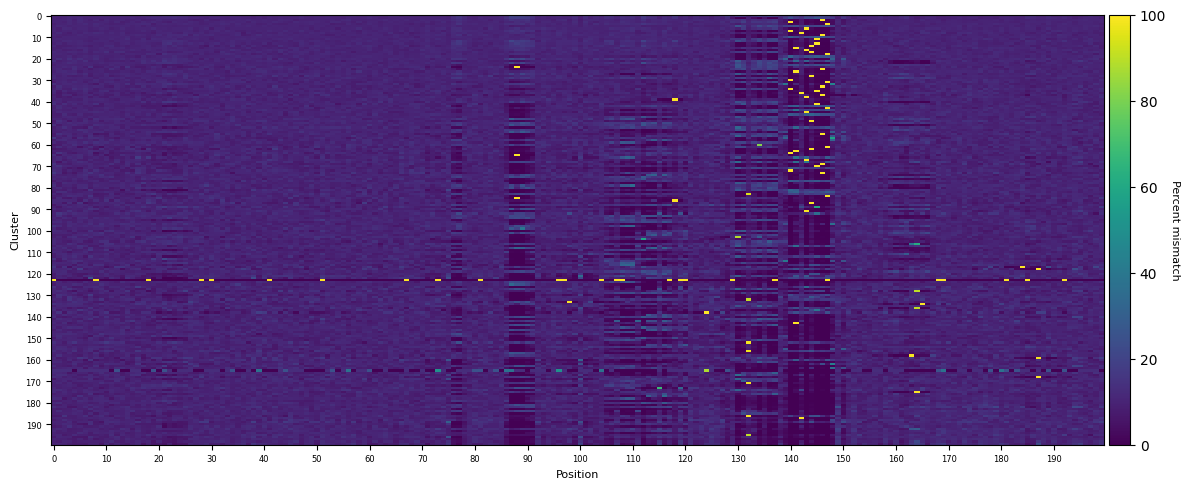

(<Figure size 1200x500 with 2 Axes>,
 <Axes: xlabel='Position', ylabel='Cluster'>)

In [105]:
# cluster summary matrix - mismatch (% mismatch of seqs in cluster to WT reference)
meta.plot_msm(column="Reference", figsize=(12, 5))

/tmp/ipykernel_3159950/2912205731.py:28: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


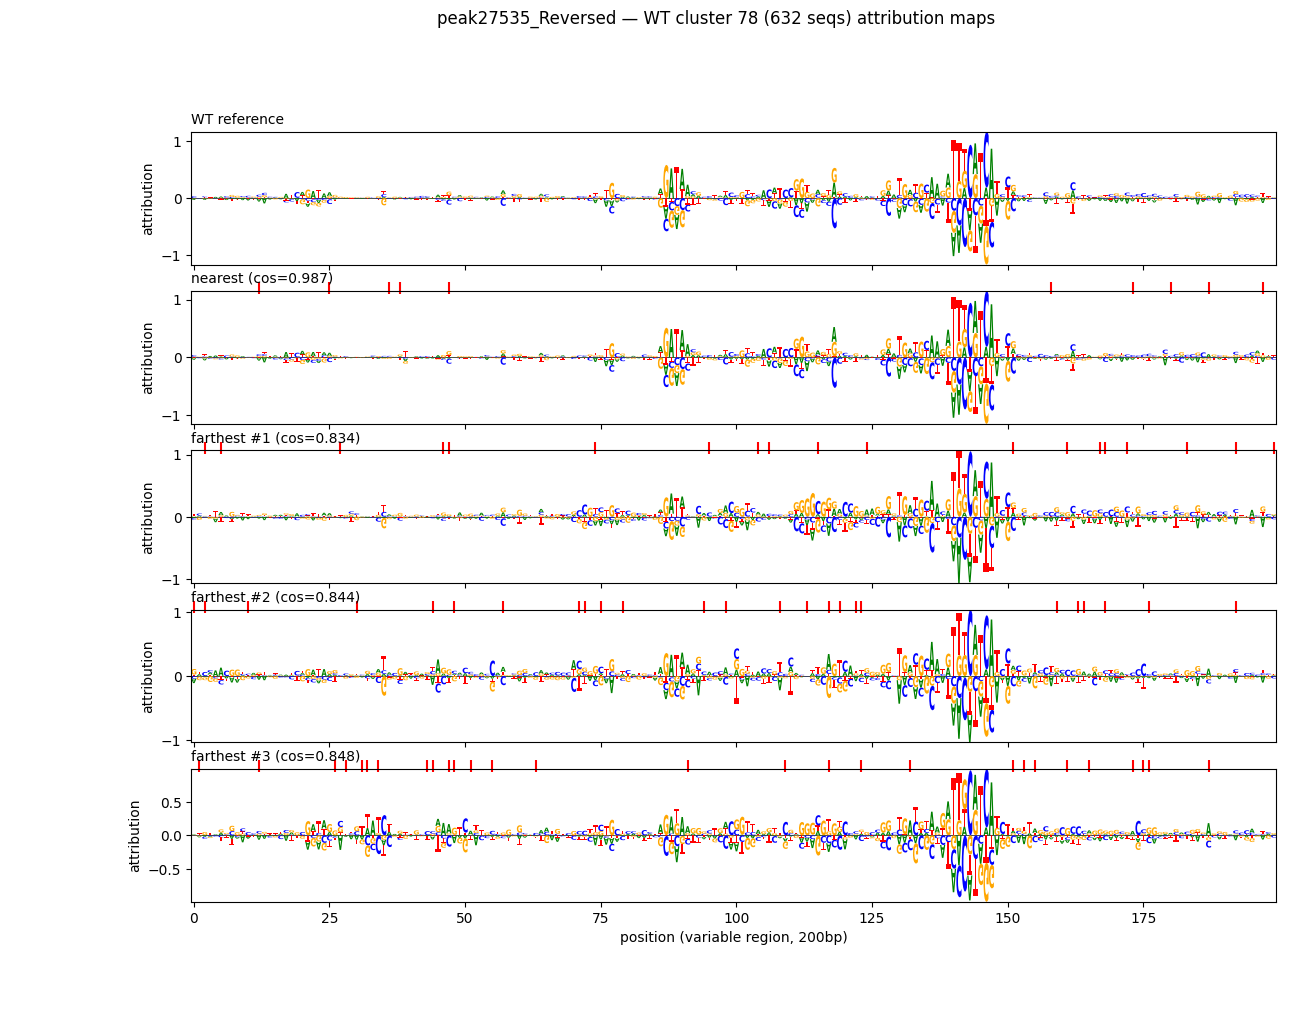

In [106]:
# raw attribution maps: WT vs nearest + top-3 farthest cluster members by cosine sim of attribution
wt_cluster = cluster_labels[0]                          # ref_idx=0 = WT reference
wt_int = var_seqs[0].argmax(-1)                         # WT bases in variable region
is_variant = (var_seqs.argmax(-1) != wt_int).any(1)     # differs from WT somewhere (excludes idx 0 + exact-WT dupes)

members_all = np.where(cluster_labels == wt_cluster)[0]
members = members_all[is_variant[members_all]]          # variants only; WT shown separately
flat = attributions[members].reshape(len(members), -1)
cos = flat @ attributions[0].ravel() / (np.linalg.norm(flat, axis=1) * np.linalg.norm(attributions[0]))

si = np.argsort(cos)                                    # ascending: si[0] = farthest, si[-1] = nearest variant
# (title, attribution map, seq index for red mutation ticks)
panels = [("WT reference", attributions[0], 0),
          (f"nearest (cos={cos[si[-1]]:.3f})", attributions[members[si[-1]]], members[si[-1]])]
for rank in range(3):
    panels.append((f"farthest #{rank+1} (cos={cos[si[rank]]:.3f})", attributions[members[si[rank]]], members[si[rank]]))

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2 * len(panels)), sharex=True)
for ax, (title, arr, idx) in zip(axes, panels):
    logomaker.Logo(pd.DataFrame(arr, columns=list("ACGT")), ax=ax)
    mut = np.where(var_seqs[idx].argmax(-1) != wt_int)[0]   # positions mutated from WT
    ax.plot(mut, np.full(len(mut), 1.02), marker='|', linestyle='None', color='red',
            markersize=9, markeredgewidth=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("attribution")
axes[-1].set_xlabel("position (variable region, 200bp)")
fig.suptitle(f"{SEQ_ID} — WT cluster {wt_cluster} ({len(members_all)} seqs) attribution maps", y=1.002)
plt.tight_layout()

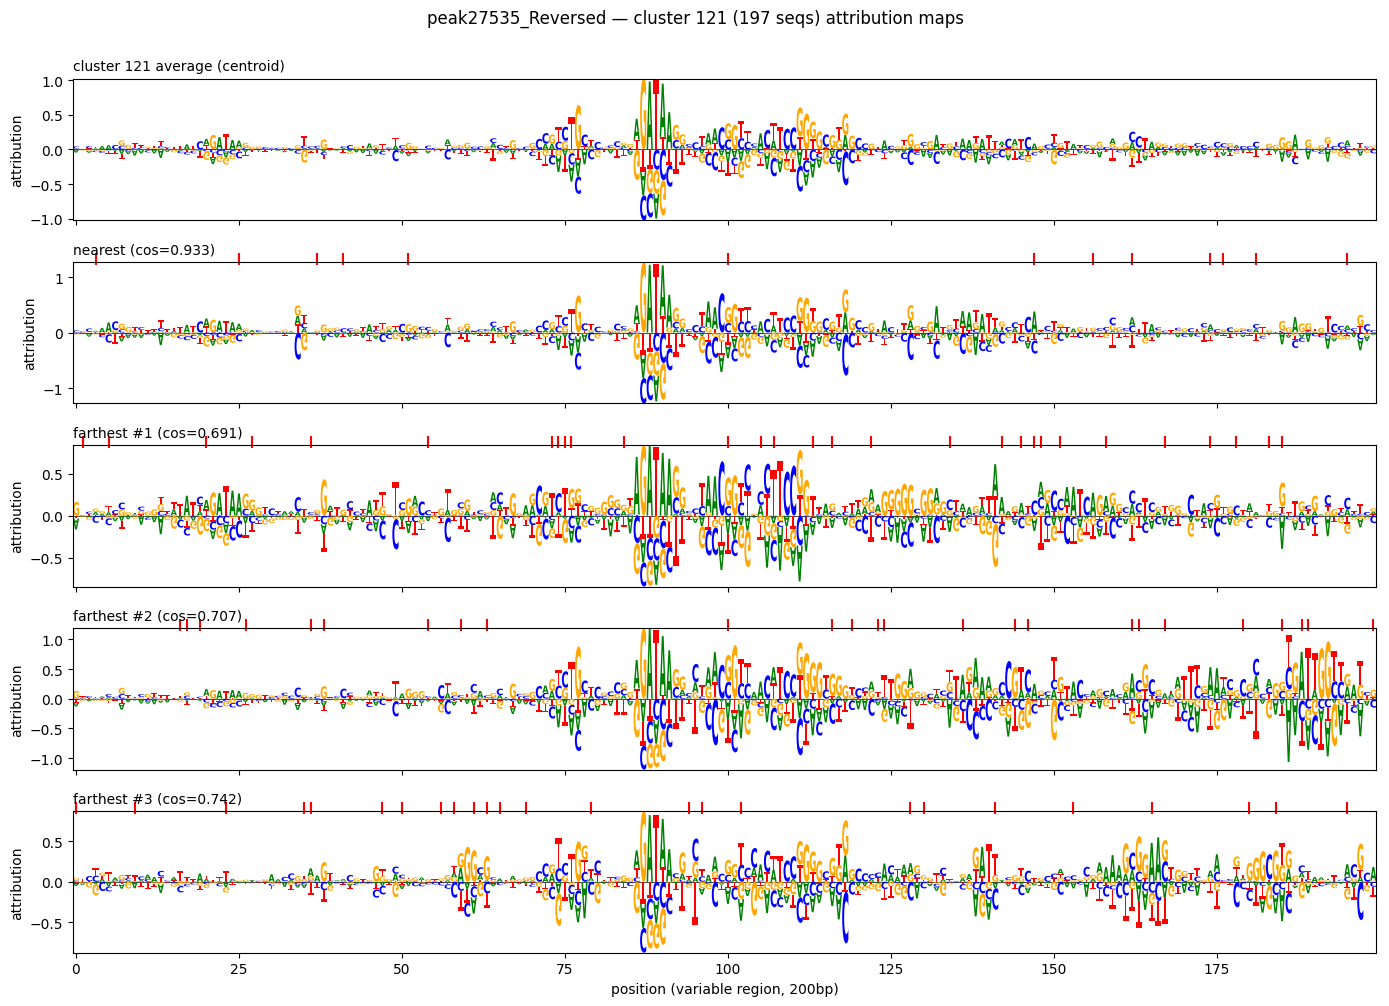

In [110]:
# pick any cluster (raw k-means label) -> centroid + nearest + top-3 farthest members
CLUSTER = 121

wt_int = var_seqs[0].argmax(-1)                         # WT bases in variable region
is_variant = (var_seqs.argmax(-1) != wt_int).any(1)     # differs from WT (excludes idx 0 + exact-WT dupes)

members_all = np.where(cluster_labels == CLUSTER)[0]
center = attributions[members_all].mean(0)             # cluster average = anchor (no WT here)
members = members_all[is_variant[members_all]]          # rank variants only
flat = attributions[members].reshape(len(members), -1)
cos = flat @ center.ravel() / (np.linalg.norm(flat, axis=1) * np.linalg.norm(center))

si = np.argsort(cos)                                    # ascending: si[0] = farthest, si[-1] = nearest
# (title, attribution map, seq index for red mutation ticks; None = average, no ticks)
panels = [(f"cluster {CLUSTER} average (centroid)", center, None),
          (f"nearest (cos={cos[si[-1]]:.3f})", attributions[members[si[-1]]], members[si[-1]])]
for rank in range(3):
    panels.append((f"farthest #{rank+1} (cos={cos[si[rank]]:.3f})", attributions[members[si[rank]]], members[si[rank]]))

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2 * len(panels)), sharex=True)
for ax, (title, arr, idx) in zip(axes, panels):
    logomaker.Logo(pd.DataFrame(arr, columns=list("ACGT")), ax=ax)
    if idx is not None:
        mut = np.where(var_seqs[idx].argmax(-1) != wt_int)[0]   # positions mutated from WT
        ax.plot(mut, np.full(len(mut), 1.02), marker='|', linestyle='None', color='red',
                markersize=9, markeredgewidth=1.5, transform=ax.get_xaxis_transform(), clip_on=False)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("attribution")
axes[-1].set_xlabel("position (variable region, 200bp)")
fig.suptitle(f"{SEQ_ID} — cluster {CLUSTER} ({len(members_all)} seqs) attribution maps", y=1.002)
plt.tight_layout()

Text(0, 0.5, 'cosine sim to cluster centroid')

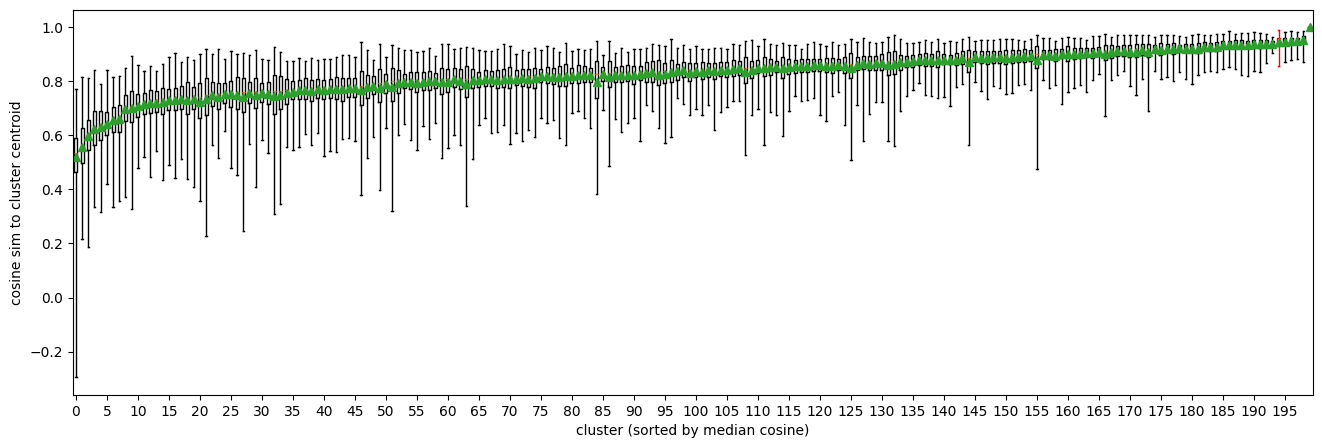

In [111]:
# per-cluster member-to-centroid cosine sim, as box plots (whiskers = full range, ● = mean)
cos_by_cluster = []
for c in range(cluster_labels.max() + 1):
    m = attributions[cluster_labels == c].reshape((cluster_labels == c).sum(), -1)
    ctr = m.mean(0)
    cos_by_cluster.append(m @ ctr / (np.linalg.norm(m, axis=1) * np.linalg.norm(ctr)))

plt.figure(figsize=(16, 5))
order = sorted(range(len(cos_by_cluster)), key=lambda i: np.median(cos_by_cluster[i]))
data = [cos_by_cluster[i] for i in order]
bp = plt.boxplot(data, showmeans=True, showfliers=False, whis=(0, 100))
wt_pos = order.index(cluster_labels[0])                 # WT cluster's slot after sorting
bp['boxes'][wt_pos].set_color('red')
bp['medians'][wt_pos].set_color('red')
for k in ('whiskers', 'caps'):
    bp[k][2 * wt_pos].set_color('red'); bp[k][2 * wt_pos + 1].set_color('red')
plt.xticks(range(1, len(data) + 1, 5), range(0, len(data), 5))
plt.xlabel("cluster (sorted by median cosine)")
plt.ylabel("cosine sim to cluster centroid")

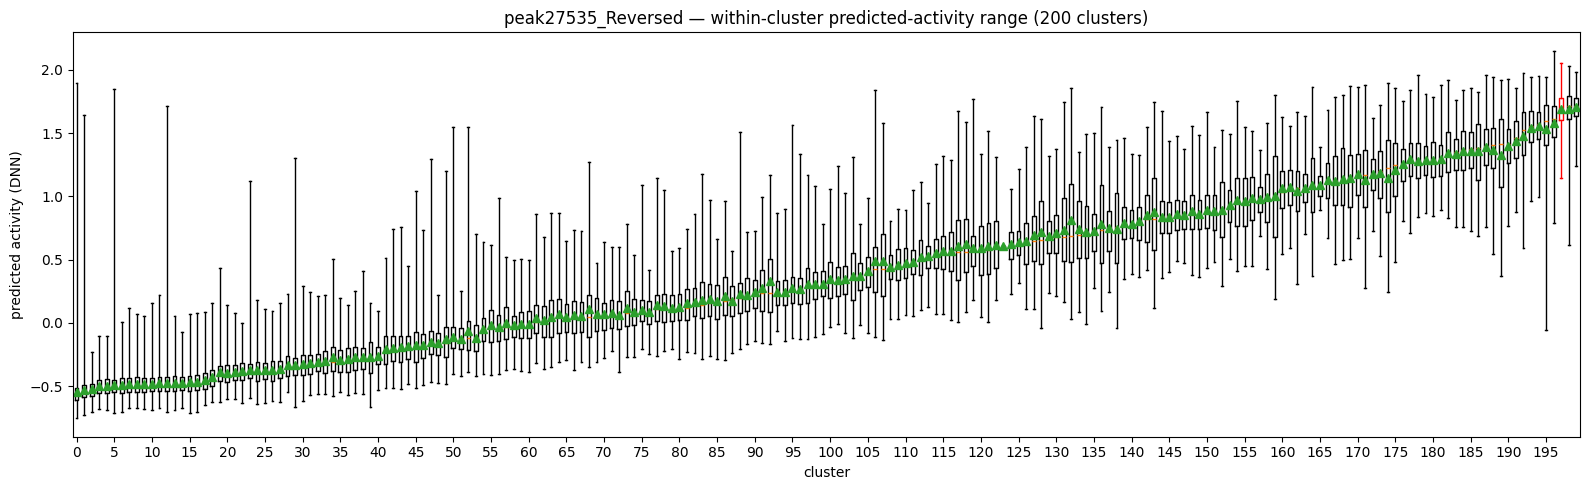

In [109]:
# same per-cluster box plots, but DNN predicted activity instead of cosine sim
pred_by_cluster = [predictions[cluster_labels == c] for c in range(cluster_labels.max() + 1)]

plt.figure(figsize=(16, 5))
order = sorted(range(len(pred_by_cluster)), key=lambda i: np.median(pred_by_cluster[i]))
data = [pred_by_cluster[i] for i in order]
bp = plt.boxplot(data, showmeans=True, showfliers=False, whis=(0, 100))
wt_pos = order.index(cluster_labels[0])                 # WT cluster's slot after sorting
bp['boxes'][wt_pos].set_color('red')
bp['medians'][wt_pos].set_color('red')
for k in ('whiskers', 'caps'):
    bp[k][2 * wt_pos].set_color('red'); bp[k][2 * wt_pos + 1].set_color('red')
plt.xticks(range(1, len(pred_by_cluster) + 1, 5), range(0, len(pred_by_cluster), 5))
plt.xlabel("cluster")
plt.ylabel("predicted activity (DNN)")
plt.title(f"{SEQ_ID} — within-cluster predicted-activity range ({len(pred_by_cluster)} clusters)")
plt.tight_layout()